In [1]:
# ============================================================
# FUNCTION 1 — WEEK 6
# Clean rebuild in a new notebook
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.spatial import cKDTree

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

print("Week 6 Function 1 setup complete")

Week 6 Function 1 setup complete


In [2]:
# ------------------------------------------------------------
# LOAD ORIGINAL DATA
# ------------------------------------------------------------

X = np.load("function1/initial_inputs.npy")
Y = np.load("function1/initial_outputs.npy").reshape(-1)

print("Original X shape:", X.shape)
print("Original Y shape:", Y.shape)

Original X shape: (10, 2)
Original Y shape: (10,)


In [3]:
# ------------------------------------------------------------
# ADD WEEKS 1–5 ONCE
# ------------------------------------------------------------

weekly_X = np.array([
    [0.737954, 0.758348],   # Week 1
    [0.773956, 0.438878],   # Week 2
    [0.676583, 0.811941],   # Week 3
    [0.615097, 1.000000],   # Week 4
    [0.989574, 0.008694]    # Week 5
])

weekly_Y = np.array([
    -2.857650951335033e-21,
     9.656222973626152e-41,
    -3.592807837147156e-26,
    -1.1193558896664302e-96,
     0.0
])

X = np.vstack([X, weekly_X])
Y = np.concatenate([Y, weekly_Y])

print("Week 6 training X shape:", X.shape)
print("Week 6 training Y shape:", Y.shape)

print("\nMost recent observation:")
print("Input:", weekly_X[-1])
print("Output:", weekly_Y[-1])

Week 6 training X shape: (15, 2)
Week 6 training Y shape: (15,)

Most recent observation:
Input: [0.989574 0.008694]
Output: 0.0


In [4]:
# ============================================================
# FUNCTION 1 — WEEK 6 OPTIMISATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.spatial import cKDTree

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

# ------------------------------------------------------------
# 1. TRANSFORM OUTPUTS
#
# Function 1 values are extremely close to zero.
# We therefore model closeness to zero rather than raw Y.
# Larger score = closer to zero.
# ------------------------------------------------------------

epsilon = 1e-120

Y_score = -np.log10(
    np.abs(Y) + epsilon
)

best_index = np.argmax(Y_score)
best_x = X[best_index]
best_score = Y_score[best_index]

print("Best point under closeness score:", best_x)
print("Original output:", Y[best_index])
print("Closeness score:", best_score)


# ------------------------------------------------------------
# 2. FIT ARD MATERN GAUSSIAN PROCESS
# ------------------------------------------------------------

kernel = (
    C(1.0, (1e-3, 1e3))
    *
    Matern(
        length_scale=[0.15, 0.15],
        length_scale_bounds=(0.005, 2.0),
        nu=2.5
    )
    +
    WhiteKernel(
        noise_level=1e-6,
        noise_level_bounds=(1e-10, 1e-2)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=8,
    random_state=61
)

gp.fit(X, Y_score)

print("\nFitted kernel:")
print(gp.kernel_)


# ------------------------------------------------------------
# 3. INSPECT LENGTHSCALES
# ------------------------------------------------------------

lengthscales = np.asarray(
    gp.kernel_.k1.k2.length_scale
)

print("\nFitted lengthscales:")
print("x1:", lengthscales[0])
print("x2:", lengthscales[1])


# ------------------------------------------------------------
# 4. GENERATE WEEK 6 CANDIDATES
#
# Week 5 found:
# [0.989574, 0.008694] -> output 0
#
# So we now heavily exploit the upper-left corner.
# ------------------------------------------------------------

rng = np.random.default_rng(61)

week5_point = np.array([
    0.989574,
    0.008694
])

# A. Very tight search around Week 5
very_local = rng.normal(
    loc=week5_point,
    scale=[0.003, 0.003],
    size=(5000, 2)
)

# B. Slightly wider local search
local = rng.normal(
    loc=week5_point,
    scale=[0.012, 0.012],
    size=(5000, 2)
)

# C. Search x1 = 1 boundary
x1_boundary = np.column_stack([
    np.ones(3000),
    rng.uniform(
        0.0,
        0.06,
        size=3000
    )
])

# D. Search x2 = 0 boundary
x2_boundary = np.column_stack([
    rng.uniform(
        0.92,
        1.00,
        size=3000
    ),
    np.zeros(3000)
])

# E. Exact corner
corner = np.array([
    [1.0, 0.0]
])

# F. Slightly wider corner-region exploration
wider_corner = np.column_stack([
    rng.uniform(
        0.85,
        1.00,
        size=3000
    ),
    rng.uniform(
        0.00,
        0.15,
        size=3000
    )
])

candidates = np.vstack([
    very_local,
    local,
    x1_boundary,
    x2_boundary,
    corner,
    wider_corner
])

candidates = np.clip(
    candidates,
    0,
    1
)

print("\nCandidates before filtering:", len(candidates))


# ------------------------------------------------------------
# 5. REMOVE POINTS TOO CLOSE TO EXISTING OBSERVATIONS
# ------------------------------------------------------------

tree = cKDTree(X)

minimum_distance, _ = tree.query(
    candidates,
    k=1
)

keep = minimum_distance > 0.0015

candidates = candidates[keep]

print("Candidates after filtering:", len(candidates))


# ------------------------------------------------------------
# 6. GP PREDICTIONS
# ------------------------------------------------------------

mean, std = gp.predict(
    candidates,
    return_std=True
)


# ------------------------------------------------------------
# 7. EXPECTED IMPROVEMENT
# ------------------------------------------------------------

xi = 0.001

improvement = (
    mean
    - best_score
    - xi
)

with np.errstate(
    divide="ignore",
    invalid="ignore"
):

    z = improvement / std

    ei = (
        improvement * norm.cdf(z)
        + std * norm.pdf(z)
    )

ei[std < 1e-12] = 0


# ------------------------------------------------------------
# 8. SMALL UCB COMPONENT
# ------------------------------------------------------------

kappa = 0.30

ucb = mean + kappa * std


# ------------------------------------------------------------
# 9. NORMALISE ACQUISITION SCORES
# ------------------------------------------------------------

ei_norm = (
    ei - ei.min()
) / (
    np.ptp(ei) + 1e-12
)

ucb_norm = (
    ucb - ucb.min()
) / (
    np.ptp(ucb) + 1e-12
)

# Strong exploitation this week
acquisition = (
    0.90 * ei_norm
    + 0.10 * ucb_norm
)


# ------------------------------------------------------------
# 10. CHOOSE WEEK 6 QUERY
# ------------------------------------------------------------

chosen_index = np.argmax(acquisition)

week6_query = candidates[
    chosen_index
]


# ------------------------------------------------------------
# 11. PRINT WEEK 6 RESULT
# ------------------------------------------------------------

print("\nSuggested Week 6 query:")
print(week6_query)

print("\nPortal format:")
print(
    "-".join(
        f"{value:.6f}"
        for value in week6_query
    )
)

print("\nPredicted closeness score:",
      mean[chosen_index])

print("Predicted uncertainty:",
      std[chosen_index])

print("Expected Improvement:",
      ei[chosen_index])

print(
    "Distance from Week 5:",
    np.linalg.norm(
        week6_query - week5_point
    )
)

print(
    "Distance from exact corner [1, 0]:",
    np.linalg.norm(
        week6_query
        - np.array([1.0, 0.0])
    )
)


# ------------------------------------------------------------
# 12. SHOW TOP 10 CANDIDATES
# ------------------------------------------------------------

top_indices = np.argsort(
    acquisition
)[-10:][::-1]

print("\nTOP 10 WEEK 6 CANDIDATES")
print("-" * 65)

for rank, idx in enumerate(
    top_indices,
    start=1
):
    print(
        f"{rank:2d}. "
        f"point={candidates[idx]}  "
        f"mean={mean[idx]:.4f}  "
        f"std={std[idx]:.4f}  "
        f"EI={ei[idx]:.4f}  "
        f"acq={acquisition[idx]:.4f}"
    )

Best point under closeness score: [0.989574 0.008694]
Original output: 0.0
Closeness score: 120.0

Fitted kernel:
1.49**2 * Matern(length_scale=[0.313, 0.357], nu=2.5) + WhiteKernel(noise_level=1e-10)

Fitted lengthscales:
x1: 0.31267086461255084
x2: 0.3573495340011836

Candidates before filtering: 19001
Candidates after filtering: 18398

Suggested Week 6 query:
[0.92711818 0.14937544]

Portal format:
0.927118-0.149375

Predicted closeness score: 139.8813975094069
Predicted uncertainty: 12.03939585016787
Expected Improvement: 20.1280939737328
Distance from Week 5: 0.1539220500038621
Distance from exact corner [1, 0]: 0.16620704648482212

TOP 10 WEEK 6 CANDIDATES
-----------------------------------------------------------------
 1. point=[0.92711818 0.14937544]  mean=139.8814  std=12.0394  EI=20.1281  acq=1.0000
 2. point=[0.92394854 0.14903916]  mean=139.8890  std=11.8767  EI=20.1191  acq=0.9994
 3. point=[0.91844847 0.149463  ]  mean=139.8991  std=11.6343  EI=20.1055  acq=0.9986
 4. p

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


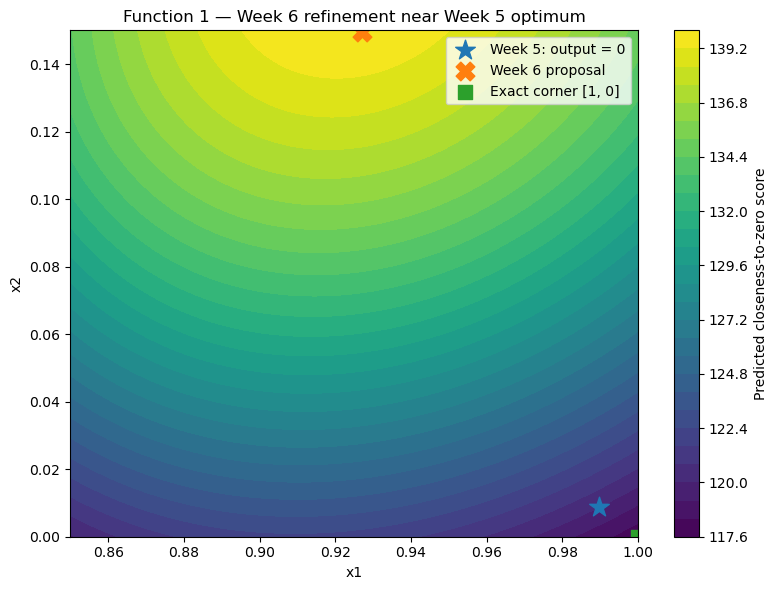

In [5]:
# ============================================================
# FUNCTION 1 — WEEK 6 VISUALISATION
# ============================================================

grid_size = 160

x1_values = np.linspace(
    0.85,
    1.00,
    grid_size
)

x2_values = np.linspace(
    0.00,
    0.15,
    grid_size
)

X1_grid, X2_grid = np.meshgrid(
    x1_values,
    x2_values
)

grid_points = np.column_stack([
    X1_grid.ravel(),
    X2_grid.ravel()
])

grid_mean, grid_std = gp.predict(
    grid_points,
    return_std=True
)

grid_mean = grid_mean.reshape(
    X1_grid.shape
)

plt.figure(figsize=(8, 6))

contour = plt.contourf(
    X1_grid,
    X2_grid,
    grid_mean,
    levels=30
)

plt.colorbar(
    contour,
    label="Predicted closeness-to-zero score"
)

# Week 5
plt.scatter(
    0.989574,
    0.008694,
    marker="*",
    s=220,
    label="Week 5: output = 0"
)

# Week 6 proposal
plt.scatter(
    week6_query[0],
    week6_query[1],
    marker="X",
    s=180,
    label="Week 6 proposal"
)

# Exact corner
plt.scatter(
    1.0,
    0.0,
    marker="s",
    s=100,
    label="Exact corner [1, 0]"
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title(
    "Function 1 — Week 6 refinement near Week 5 optimum"
)

plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# FUNCTION 1 — WEEK 6 REDO
# STRICT CORNER REFINEMENT
# ============================================================

import numpy as np
from scipy.stats import norm
from scipy.spatial import cKDTree

rng = np.random.default_rng(161)

week5_point = np.array([
    0.989574,
    0.008694
])

corner = np.array([
    1.0,
    0.0
])

# ------------------------------------------------------------
# 1. VERY TIGHT SEARCH AROUND WEEK 5
# ------------------------------------------------------------

very_local = rng.normal(
    loc=week5_point,
    scale=[
        0.0025,
        0.0025
    ],
    size=(10000, 2)
)

# ------------------------------------------------------------
# 2. SLIGHTLY WIDER LOCAL SEARCH
# ------------------------------------------------------------

local = rng.normal(
    loc=week5_point,
    scale=[
        0.006,
        0.006
    ],
    size=(10000, 2)
)

# ------------------------------------------------------------
# 3. x1 = 1 BOUNDARY
# ------------------------------------------------------------

x1_boundary = np.column_stack([
    np.ones(8000),
    rng.uniform(
        0.0005,
        0.025,
        size=8000
    )
])

# ------------------------------------------------------------
# 4. x2 = 0 BOUNDARY
# ------------------------------------------------------------

x2_boundary = np.column_stack([
    rng.uniform(
        0.965,
        0.9995,
        size=8000
    ),
    np.zeros(8000)
])

# ------------------------------------------------------------
# 5. REGION BETWEEN WEEK 5 AND EXACT CORNER
# ------------------------------------------------------------

weights = rng.uniform(
    0,
    1,
    size=(6000, 1)
)

toward_corner = (
    weights * week5_point
    +
    (1 - weights) * corner
)

toward_corner += rng.normal(
    0,
    [
        0.0015,
        0.0015
    ],
    size=(6000, 2)
)

# ------------------------------------------------------------
# 6. SMALL CONTROLLED CORNER BOX
# ------------------------------------------------------------

corner_box = np.column_stack([
    rng.uniform(
        0.965,
        1.0,
        size=6000
    ),
    rng.uniform(
        0.0,
        0.035,
        size=6000
    )
])

candidates = np.vstack([
    very_local,
    local,
    x1_boundary,
    x2_boundary,
    toward_corner,
    corner_box
])

candidates = np.clip(
    candidates,
    0,
    1
)

print(
    "Candidates before filtering:",
    len(candidates)
)

Candidates before filtering: 48000


In [7]:
# ============================================================
# REMOVE POINTS TOO CLOSE TO EXISTING OBSERVATIONS
# ============================================================

tree = cKDTree(X)

minimum_distance, _ = tree.query(
    candidates,
    k=1
)

keep = minimum_distance > 0.001

candidates = candidates[keep]

print(
    "Candidates after filtering:",
    len(candidates)
)

Candidates after filtering: 46938


In [8]:
# ============================================================
# GP PREDICTIONS
# ============================================================

mean, std = gp.predict(
    candidates,
    return_std=True
)

In [9]:
# ============================================================
# EXPECTED IMPROVEMENT
# ============================================================

xi = 0.001

improvement = (
    mean
    - best_score
    - xi
)

with np.errstate(
    divide="ignore",
    invalid="ignore"
):

    z = improvement / std

    ei = (
        improvement * norm.cdf(z)
        +
        std * norm.pdf(z)
    )

ei[std < 1e-12] = 0


# ============================================================
# UCB
# ============================================================

kappa = 0.15

ucb = (
    mean
    + kappa * std
)


# ============================================================
# NORMALISE
# ============================================================

ei_norm = (
    ei - ei.min()
) / (
    np.ptp(ei)
    + 1e-12
)

ucb_norm = (
    ucb - ucb.min()
) / (
    np.ptp(ucb)
    + 1e-12
)


# ============================================================
# DISTANCE FROM WEEK 5
#
# Smaller distance is preferred.
# ============================================================

distance_week5 = np.linalg.norm(
    candidates - week5_point,
    axis=1
)

distance_norm = (
    distance_week5
    - distance_week5.min()
) / (
    np.ptp(distance_week5)
    + 1e-12
)


# ============================================================
# FINAL ACQUISITION
#
# 85% EI
# 10% UCB
# 5% penalty for unnecessary movement
# ============================================================

acquisition = (
    0.85 * ei_norm
    +
    0.10 * ucb_norm
    -
    0.05 * distance_norm
)

chosen_index = np.argmax(
    acquisition
)

week6_query = candidates[
    chosen_index
]

In [10]:
# ============================================================
# FUNCTION 1 — REDONE WEEK 6 RESULT
# ============================================================

print("\nSuggested Week 6 query:")
print(week6_query)

print("\nPortal format:")
print(
    "-".join(
        f"{value:.6f}"
        for value in week6_query
    )
)

print(
    "\nPredicted closeness score:",
    mean[chosen_index]
)

print(
    "Predicted uncertainty:",
    std[chosen_index]
)

print(
    "Expected Improvement:",
    ei[chosen_index]
)

print(
    "Distance from Week 5:",
    np.linalg.norm(
        week6_query
        - week5_point
    )
)

print(
    "Distance from [1, 0]:",
    np.linalg.norm(
        week6_query
        - corner
    )
)


Suggested Week 6 query:
[0.96513991 0.03499383]

Portal format:
0.965140-0.034994

Predicted closeness score: 125.80117407232834
Predicted uncertainty: 5.2873011518719535
Expected Improvement: 6.165142555639961
Distance from Week 5: 0.035898545022591204
Distance from [1, 0]: 0.04939426711407073
